In [7]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import pandas as pd
import matplotlib.pyplot as plt

## Unvaccinated children with starting point

In [33]:
with open('RESULTS_MVP_scenarios_5deltas_true_overlap_true_capacity.json') as json_file:
    F_results = json.load(json_file)


In [34]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [35]:
grouped_results

{'S[': [{'S[Hib,9,1]': 0.0},
  {'S[Hib,2,1]': 0.0},
  {'S[Hib,8,1]': 0.0},
  {'S[Diphtheria,1,1]': 0.0},
  {'S[Hib,0,1]': 2595000.0},
  {'S[HPV,8,1]': 0.0},
  {'S[Rotavirus,7,1]': 0.0},
  {'S[Polio,9,1]': 0.0},
  {'S[Rubella,6,1]': 0.0},
  {'S[HPV,4,1]': 0.0},
  {'S[Tetanus,3,1]': 0.0},
  {'S[Rubella,3,1]': 0.0},
  {'S[HPV,6,1]': 0.0},
  {'S[HPV,0,1]': 1900000.0},
  {'S[Mumps,8,1]': 0.0},
  {'S[Polio,2,1]': 0.0},
  {'S[Mumps,4,1]': 0.0},
  {'S[Diphtheria,6,1]': 0.0},
  {'S[PCV,4,1]': 1432423082.708076},
  {'S[PCV,9,1]': 0.0},
  {'S[Measles,6,1]': 0.0},
  {'S[Tetanus,1,1]': 0.0},
  {'S[Pertussis,6,1]': 0.0},
  {'S[Measles,1,1]': 0.0},
  {'S[Diphtheria,9,1]': 0.0},
  {'S[PCV,3,1]': 3452553861.0145617},
  {'S[HPV,1,1]': 0.0},
  {'S[Polio,4,1]': 0.0},
  {'S[Hepatitis_B,2,1]': 0.0},
  {'S[Measles,4,1]': 0.0},
  {'S[Diphtheria,5,1]': 0.0},
  {'S[Hib,3,1]': 0.0},
  {'S[Hib,10,1]': 0.0},
  {'S[Rotavirus,0,1]': 14250000.0},
  {'S[HPV,10,1]': 0.0},
  {'S[Diphtheria,3,1]': 0.0},
  {'S[Mumps,7,1]'

In [36]:
# Extracting data into lists
antigen_list = []
year_list = []
value_list = []
scenario_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Splitting the key and extracting Antigen, Year, and Scenario
        parts = key.split(',')[0][2:], int(key.split(',')[1]), int(key.split(',')[2][:-1])
        
        # Appending values to lists
        antigen_list.append(parts[0])
        year_list.append(parts[1])
        scenario_list.append(parts[2])
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list,
    'Scenario': scenario_list
})

# Displaying the DataFrame
print(df)


         Antigen  Year      Value  Scenario
0            Hib     9        0.0         1
1            Hib     2        0.0         1
2            Hib     8        0.0         1
3     Diphtheria     1        0.0         1
4            Hib     0  2595000.0         1
..           ...   ...        ...       ...
127          Hib     7        0.0         1
128      Tetanus     8        0.0         1
129  Hepatitis_B     3        0.0         1
130        Mumps     1        0.0         1
131    Rotavirus     6        0.0         1

[132 rows x 4 columns]


##### 

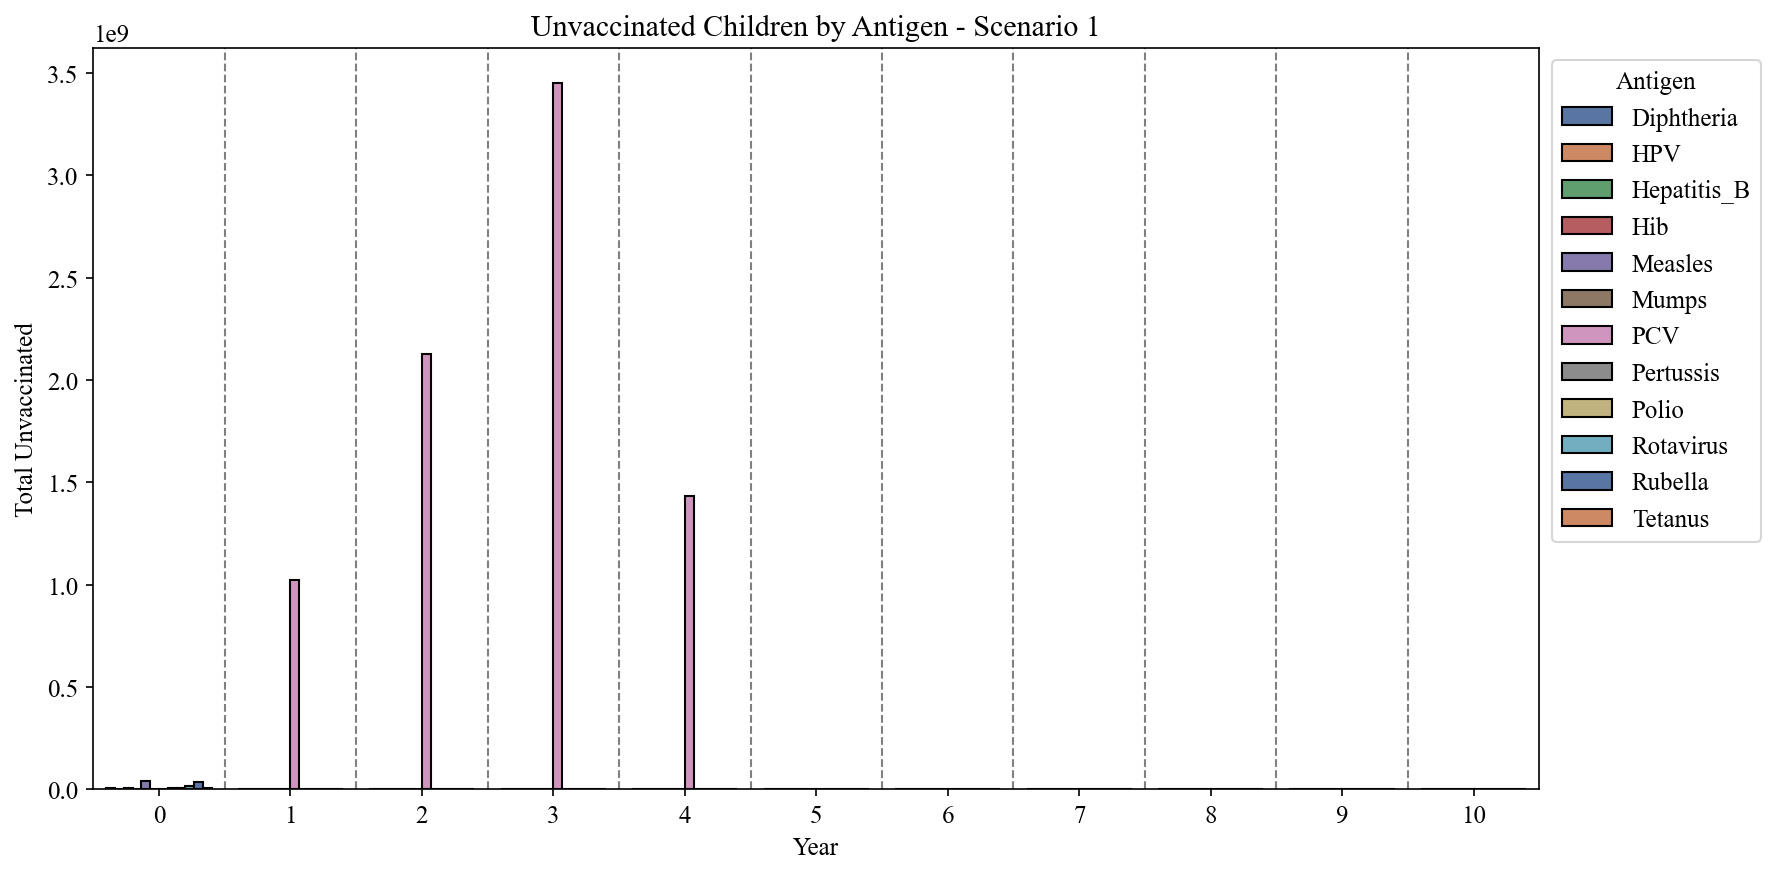

In [37]:
# iterates over all scenarios presented in the data
# Create a list of all years from 0 to 10
all_years = list(range(0, 11))

# Loop through each scenario and generate a separate plot
for scenario in df['Scenario'].unique():
    # Filter the DataFrame for the current scenario
    scenario_df = df[df['Scenario'] == scenario]

    # Grouping by Year and Antigen, and summing the Value column
    result = scenario_df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()
    result = result[result['Year'].between(0, 10)]

    # Filling missing combinations of Year and Antigen with 0.0 value
    result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

    # Melt the DataFrame to have a long format suitable for plotting
    result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

    # Set a color palette with distinct colors for each antigen
    palette = sns.color_palette("deep", n_colors=len(result['Antigen'].unique()))

    # Plotting the bar chart with seaborn
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Year', y='Value', hue='Antigen', data=result, palette=palette, edgecolor='black')  # Add edgecolor for boxes

    # Add vertical lines at each break between years (0 to 10)
    for year in all_years[1:]:
        plt.axvline(x=year - 0.5, color='gray', linestyle='--', linewidth=1)

    plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
    plt.ylim(0, df['Value'].max()+ (df['Value'].max()*0.05))
    plt.xlabel('Year')
    plt.ylabel('Total Unvaccinated')
    plt.title(f'Unvaccinated Children by Antigen - Scenario {scenario}')
    plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
    plt.tight_layout()  # Adjust layout for better visualization
    plt.show()
